# Projet Analyse de sentiment

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter 
import numpy as np
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import string
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import  TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score 
from textblob import TextBlob  
from gensim import matutils, models
import gensim

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TECHN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
import warnings 
warnings.filterwarnings("ignore") 


In [3]:
def predict_sentiment(tokenized_comment):
    # Join the tokenized words to form a sentence
    comment_text = ' '.join(tokenized_comment)
    
    # Create a TextBlob object
    blob = TextBlob(comment_text)
    
    # Get the sentiment polarity
    polarity = blob.sentiment.polarity
    
    # Determine the sentiment based on the polarity
    if polarity > 0:
        sentiment = 'positive'
    elif polarity < 0:
        sentiment = 'negative'
    else:
        sentiment = 'neutral'
    return sentiment

# Example usage:
tokenized_comment = ["I", "hate", "this", "product", "so", "much"]
result = predict_sentiment(tokenized_comment)
print(f"The sentiment is {result}") 

The sentiment is negative


## Data cleaning & exploration

In [4]:
data = pd.read_csv('amazon_reviews.csv') 
data.head() 

,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4.0,No issues.,2014-07-23,138,0,0,0,0,0.0,0.0
1,1,0mie,5.0,"Purchased this for my device, it worked as adv...",2013-10-25,409,0,0,0,0,0.0,0.0
2,2,1K3,4.0,it works as expected. I should have sprung for...,2012-12-23,715,0,0,0,0,0.0,0.0
3,3,1m2,5.0,This think has worked out great.Had a diff. br...,2013-11-21,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5.0,"Bought it with Retail Packaging, arrived legit...",2013-07-13,513,0,0,0,0,0.0,0.0


In [5]:
data.shape
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            4915 non-null   int64  
 1   reviewerName          4914 non-null   object 
 2   overall               4915 non-null   float64
 3   reviewText            4914 non-null   object 
 4   reviewTime            4915 non-null   object 
 5   day_diff              4915 non-null   int64  
 6   helpful_yes           4915 non-null   int64  
 7   helpful_no            4915 non-null   int64  
 8   total_vote            4915 non-null   int64  
 9   score_pos_neg_diff    4915 non-null   int64  
 10  score_average_rating  4915 non-null   float64
 11  wilson_lower_bound    4915 non-null   float64
dtypes: float64(3), int64(6), object(3)
memory usage: 460.9+ KB
None


In [6]:
# Remove the NaN values from the dataset
data = data.dropna() 

In [7]:
data.shape 

(4913, 12)

In [8]:
reviews = data[['overall','reviewText']] 
reviews.head() 

,overall,reviewText
1,5.0,"Purchased this for my device, it worked as adv..."
2,4.0,it works as expected. I should have sprung for...
3,5.0,This think has worked out great.Had a diff. br...
4,5.0,"Bought it with Retail Packaging, arrived legit..."
5,5.0,It's mini storage. It doesn't do anything els...


In [9]:
def sentiments(rating):
    if (rating == 5) or (rating == 4):
        return "Positive"
    elif rating == 3:
        return "Neutral"
    elif (rating == 2) or (rating == 1) or (rating == 0):
        return "Negative"
# Add sentiments to the data
reviews["Sentiment"] = reviews["overall"].apply(sentiments) 

In [10]:
reviews['text length'] = reviews['reviewText'].apply(len)

In [11]:
reviews

,overall,reviewText,Sentiment,text length
1,5.0,"Purchased this for my device, it worked as adv...",Positive,158
2,4.0,it works as expected. I should have sprung for...,Positive,166
3,5.0,This think has worked out great.Had a diff. br...,Positive,340
4,5.0,"Bought it with Retail Packaging, arrived legit...",Positive,290
5,5.0,It's mini storage. It doesn't do anything els...,Positive,282
...,...,...,...,...
4910,1.0,I bought this Sandisk 16GB Class 10 to use wit...,Negative,320
4911,5.0,Used this for extending the capabilities of my...,Positive,148
4912,5.0,Great card that is very fast and reliable. It ...,Positive,233
4913,5.0,Good amount of space for the stuff I want to d...,Positive,91


Text(0, 0.5, 'count')

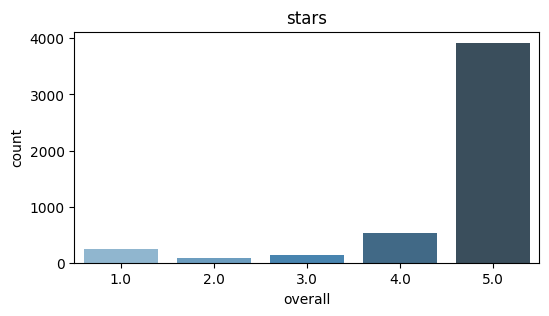

In [12]:
plt.figure(figsize=(6,3)) 
cplot = sns.countplot(x='overall', data=reviews, palette="Blues_d")
cplot.set_title('stars')
cplot.set_ylabel('count')

Text(0, 0.5, 'count')

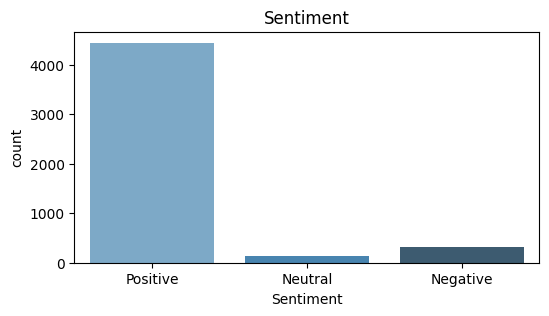

In [13]:
plt.figure(figsize=(6,3)) 
cplot = sns.countplot(x='Sentiment', data=reviews, palette="Blues_d")
cplot.set_title('Sentiment')
cplot.set_ylabel('count') 

Text(0.5, 1.0, 'Text Length Distribution')

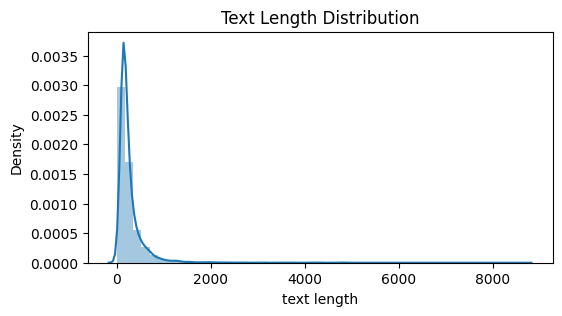

In [14]:
fig = plt.figure(figsize=(6,3))
sns.distplot(reviews['text length'], kde=True, bins=50)
plt.title('Text Length Distribution') 

In [15]:
cachedStopWords = stopwords.words("english")

def remove_punc_stopword(text):

    remove_punc = [word for word in text.lower() if word not in string.punctuation]
    remove_punc = ''.join(remove_punc)
    return [word for word in remove_punc.split() if word not in cachedStopWords] 

In [16]:
text = reviews[['overall','reviewText']]
text.head()

,overall,reviewText
1,5.0,"Purchased this for my device, it worked as adv..."
2,4.0,it works as expected. I should have sprung for...
3,5.0,This think has worked out great.Had a diff. br...
4,5.0,"Bought it with Retail Packaging, arrived legit..."
5,5.0,It's mini storage. It doesn't do anything els...


In [17]:
cleaned_text = text.copy()
cleaned_text['reviewText'] = reviews['reviewText'].apply(remove_punc_stopword) 

In [18]:
cleaned_text 

,overall,reviewText
1,5.0,"[purchased, device, worked, advertised, never,..."
2,4.0,"[works, expected, sprung, higher, capacity, th..."
3,5.0,"[think, worked, greathad, diff, bran, 64gb, ca..."
4,5.0,"[bought, retail, packaging, arrived, legit, or..."
5,5.0,"[mini, storage, doesnt, anything, else, suppos..."
...,...,...
4910,1.0,"[bought, sandisk, 16gb, class, 10, use, htc, i..."
4911,5.0,"[used, extending, capabilities, samsung, galax..."
4912,5.0,"[great, card, fast, reliable, comes, optional,..."
4913,5.0,"[good, amount, space, stuff, want, fits, gopro..."


In [19]:
def plot_Freq(data):
    FreqDist(np.concatenate(data.reviewText.reset_index(drop=True))).plot(20, cumulative=False)

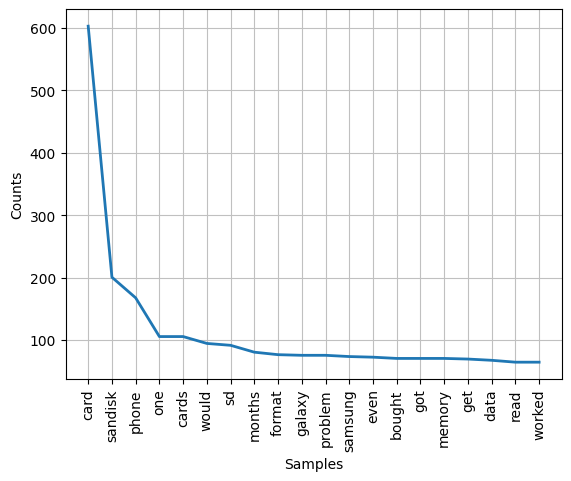

In [20]:
plot_Freq(cleaned_text[cleaned_text['overall']==1])

In [21]:
""""def reviewCloud(star):
    startext = ' '.join(text[text['overall']==star]['reviewText'])
    wordcloud = WordCloud(
        width = 3000,
        height = 2000,
        background_color = 'black',
        stopwords = STOPWORDS).generate(str(startext))

    fig = plt.figure(
        figsize = (10, 7),
        facecolor = 'k',
        edgecolor = 'k')
    plt.imshow(wordcloud, interpolation = 'bilinear')
    plt.axis('off')
    plt.tight_layout(pad=0)"""

'"def reviewCloud(star):\n    startext = \' \'.join(text[text[\'overall\']==star][\'reviewText\'])\n    wordcloud = WordCloud(\n        width = 3000,\n        height = 2000,\n        background_color = \'black\',\n        stopwords = STOPWORDS).generate(str(startext))\n\n    fig = plt.figure(\n        figsize = (10, 7),\n        facecolor = \'k\',\n        edgecolor = \'k\')\n    plt.imshow(wordcloud, interpolation = \'bilinear\')\n    plt.axis(\'off\')\n    plt.tight_layout(pad=0)'

In [22]:
""""reviewCloud(1)"""

'"reviewCloud(1)'

## Modeling

In [23]:
# Split Dataset
def split_dataset(dataframe, X, y):
  train_x, test_x, train_y, test_y = train_test_split(X, y, random_state=1)
  return train_x, test_x, train_y, test_y


In [24]:
from nltk.sentiment import SentimentIntensityAnalyzer #analyser le sentiment du texte dans la colonne 
from sklearn.preprocessing import LabelEncoder
# cette fonction crée une nouvelle colonne contenant des labels numériques en fonction du sentiment du texte dans une autre colonne. Elle renvoie ensuite les données texte et les labels pour une utilisation ultérieure dans la modélisation ou l'analyse.
# Create Lables
def create_label(dataframe, dependent_var, independent_var):
  sia = SentimentIntensityAnalyzer()
  dataframe[independent_var] = dataframe[dependent_var].apply(lambda x: "pos" if sia.polarity_scores(x)["compound"] > 0 else "neg")
  dataframe[independent_var] = LabelEncoder().fit_transform(dataframe[independent_var])

  X = dataframe[dependent_var]
  y = dataframe[independent_var]

  return X, y

In [25]:
X, y = create_label(data, "reviewText", "sentiment_label")

In [26]:
train_x, test_x, train_y, test_y = split_dataset(data, X, y)

In [27]:
#créer des représentations numériques de ces données.Elle renvoie ces représentations sous forme de matrives
#Les valeurs dans la matrice indiquent la fréquence d'apparition de chaque mot dans chaque document.
def create_features_count(train_x, test_x):
  # Count Vectors
  vectorizer = CountVectorizer()
  x_train_count_vectorizer = vectorizer.fit_transform(train_x)
  x_test_count_vectorizer = vectorizer.fit_transform(test_x)

  return x_train_count_vectorizer, x_test_count_vectorizer

In [28]:
x_train_count_vectorizer, x_test_count_vectorizer = create_features_count(train_x, test_x)

In [29]:
#TF-IDF permet de distinguer les mots les plus significatifs dans un document, en tenant compte de leur fréquence dans ce document et de leur rareté dans l'ensemble des documents.
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
def create_features_TFIDF_word(train_x, test_x):
  # TF-IDF word
  tf_idf_word_vectorizer = TfidfVectorizer()
  x_train_tf_idf_word = tf_idf_word_vectorizer.fit_transform(train_x)
  x_test_tf_idf_word = tf_idf_word_vectorizer.fit_transform(test_x)
#Les valeurs dans la matrice indiquent les scores TF-IDF de chaque mot dans chaque document.
  return x_train_tf_idf_word, x_test_tf_idf_word

In [30]:
x_train_tf_idf_word, x_test_tf_idf_word = create_features_TFIDF_word(train_x, test_x)

In [31]:
#permet de capturer des relations entre les mots,
#sont des séquences de mots consécutives
#la fonction va considérer des n-grammes de 2 à 3 mots (bigrammes et trigrammes)
def create_features_TFIDF_ngram(train_x, test_x):
  # TF-IDF ngram
  tf_idf_ngram_vectorizer = TfidfVectorizer(ngram_range=(2,3))
  x_train_tf_idf_ngram = tf_idf_ngram_vectorizer.fit_transform(train_x)
  x_test_tf_idf_ngram = tf_idf_ngram_vectorizer.fit_transform(test_x)

  return x_train_tf_idf_ngram, x_test_tf_idf_ngram

In [32]:
x_train_tf_idf_ngram, x_test_tf_idf_ngram = create_features_TFIDF_ngram(train_x, test_x)

In [33]:
# la fonction va analyser les caractères individuels plutôt que les mots.
#ux séquences de caractères (caractères individuels ou n-grammes de caractères)
def create_features_TFIDF_chars(train_x, test_x):
  # TF-IDF Characters
  tf_idf_chars_vectorizer = TfidfVectorizer(analyzer="char", ngram_range=(2,3))
  x_train_tf_idf_chars = tf_idf_chars_vectorizer.fit_transform(train_x)
  x_test_tf_idf_chars = tf_idf_chars_vectorizer.fit_transform(test_x)

  return x_train_tf_idf_chars, x_test_tf_idf_chars

In [34]:
x_train_tf_idf_chars, x_test_tf_idf_chars = create_features_TFIDF_chars(train_x, test_x)

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_validate, train_test_split
# Logistic Regression
def crate_model_logistic(train_x, test_x):
  # Count
  x_train_count_vectorizer, x_test_count_vectorizer = create_features_count(train_x, test_x)
  loj_count = LogisticRegression(solver='lbfgs', max_iter=1000)
  loj_model_count = loj_count.fit(x_train_count_vectorizer, train_y)
  accuracy_count = cross_val_score(loj_model_count, x_test_count_vectorizer, test_y, cv=10).mean()
  print("Accuracy - Count Vectors: %.3f" % accuracy_count)

  # TF-IDF Word
  x_train_tf_idf_word, x_test_tf_idf_word = create_features_TFIDF_word(train_x, test_x)
  loj_word = LogisticRegression(solver='lbfgs', max_iter=1000)
  loj_model_word = loj_word.fit(x_train_tf_idf_word, train_y)
  accuracy_word = cross_val_score(loj_model_word, x_test_tf_idf_word, test_y, cv=10).mean()
  print("Accuracy - TF-IDF Word: %.3f" % accuracy_word)

  # TF-IDF ngram
  x_train_tf_idf_ngram, x_test_tf_idf_ngram = create_features_TFIDF_ngram(train_x, test_x)
  loj_ngram = LogisticRegression(solver='lbfgs', max_iter=1000)
  loj_model_ngram = loj_ngram.fit(x_train_tf_idf_ngram, train_y)
  accuracy_ngram = cross_val_score(loj_model_ngram, x_test_tf_idf_ngram, test_y, cv=10).mean()
  print("Accuracy TF-IDF ngram: %.3f" % accuracy_ngram)

  # TF-IDF chars

  loj_chars = LogisticRegression(solver='lbfgs', max_iter=1000)
  loj_model_chars = loj_chars.fit(x_train_tf_idf_chars, train_y)
  accuracy_chars = cross_val_score(loj_model_chars, x_test_tf_idf_chars, test_y, cv=10).mean()
  print("Accuracy TF-IDF Characters: %.3f" % accuracy_chars)

  return loj_model_count, loj_model_word, loj_model_ngram, loj_model_chars

In [36]:
loj_model_count, loj_model_word, loj_model_ngram, loj_model_chars = crate_model_logistic(train_x, test_x)

Accuracy - Count Vectors: 0.803
Accuracy - TF-IDF Word: 0.773
Accuracy TF-IDF ngram: 0.759
Accuracy TF-IDF Characters: 0.768


In [37]:
#prediction
def predict_count(train_x, model, new_comment):
  new_comment= pd.Series(new_comment)
  new_comment = CountVectorizer().fit(train_x).transform(new_comment)
  result = model.predict(new_comment)
  if result==1:
    print("Comment is Positive")
  else:
    print("Comment is Negative")

In [38]:
# Logistic Regression
# Example input
comment="this product is very good"
# Get sentiment prediction
predict_count(train_x, model=loj_model_count, new_comment=comment)

Comment is Positive


# Detection des émotions


In [39]:

from transformers import pipeline

classifier = pipeline(task="text-classification", model="SamLowe/roberta-base-go_emotions", top_k=None)  

In [40]:
# Dans cette partie nous allons prendre seulement les commentaires
text = pd.read_csv('amazon_reviews.csv') 
text = text.dropna()  
text_only = text[['reviewText']]  
text_only.head()  

,reviewText
1,"Purchased this for my device, it worked as adv..."
2,it works as expected. I should have sprung for...
3,This think has worked out great.Had a diff. br...
4,"Bought it with Retail Packaging, arrived legit..."
5,It's mini storage. It doesn't do anything els...


In [41]:
# Cette fonction détermine l'emotion de chaque commentaire
def add_emotion(df,model) : 
    emotion_pipline = model
    emotion_1 = [] 
    emotion_2 = [] 
    i = 0
    
    for text in text_only['reviewText'] : 
        max_token_limit = 512
        text = text[:max_token_limit]
        result = emotion_pipline(text) 
        emotion_1.append(result[0][0]['label']) # Le 1er émotion qui a plus de score
        emotion_2.append(result[0][1]['label']) # Le 2ème émotion qui a plus de score
        if (i % 5 == 0) : 
            print(i)
        i += 1 
    result_df = df.copy()
    result_df['Emotion 1'] = emotion_1
    result_df['Emotion 2'] = emotion_2

    return result_df      

In [42]:
new_df = add_emotion(text_only,classifier)  

0
5
10
15
20
25
30
35
40
45
50
55
60
65
70
75
80
85
90
95
100
105
110
115
120
125
130
135
140
145
150
155
160
165
170
175
180
185
190
195
200
205
210
215
220
225
230
235
240
245
250
255
260
265
270
275
280
285
290
295
300
305
310
315
320
325
330
335
340
345
350
355
360
365
370
375
380
385
390
395
400
405
410
415
420
425
430
435
440
445
450
455
460
465
470
475
480
485
490
495
500
505
510
515
520
525
530
535
540
545
550
555
560
565
570
575
580
585
590
595
600
605
610
615
620
625
630
635
640
645
650
655
660
665
670
675
680
685
690
695
700
705
710
715
720
725
730
735
740
745
750
755
760
765
770
775
780
785
790
795
800
805
810
815
820
825
830
835
840
845
850
855
860
865
870
875
880
885
890
895
900
905
910
915
920
925
930
935
940
945
950
955
960
965
970
975
980
985
990
995
1000
1005
1010
1015
1020
1025
1030
1035
1040
1045
1050
1055
1060
1065
1070
1075
1080
1085
1090
1095
1100
1105
1110
1115
1120
1125
1130
1135
1140
1145
1150
1155
1160
1165
1170
1175
1180
1185
1190
1195
1200
1205
1210
1215
12

In [43]:
new_df 

,reviewText,Emotion 1,Emotion 2
1,"Purchased this for my device, it worked as adv...",approval,neutral
2,it works as expected. I should have sprung for...,neutral,approval
3,This think has worked out great.Had a diff. br...,admiration,approval
4,"Bought it with Retail Packaging, arrived legit...",approval,neutral
5,It's mini storage. It doesn't do anything els...,neutral,disapproval
...,...,...,...
4910,I bought this Sandisk 16GB Class 10 to use wit...,disappointment,sadness
4911,Used this for extending the capabilities of my...,neutral,approval
4912,Great card that is very fast and reliable. It ...,admiration,approval
4913,Good amount of space for the stuff I want to d...,curiosity,admiration


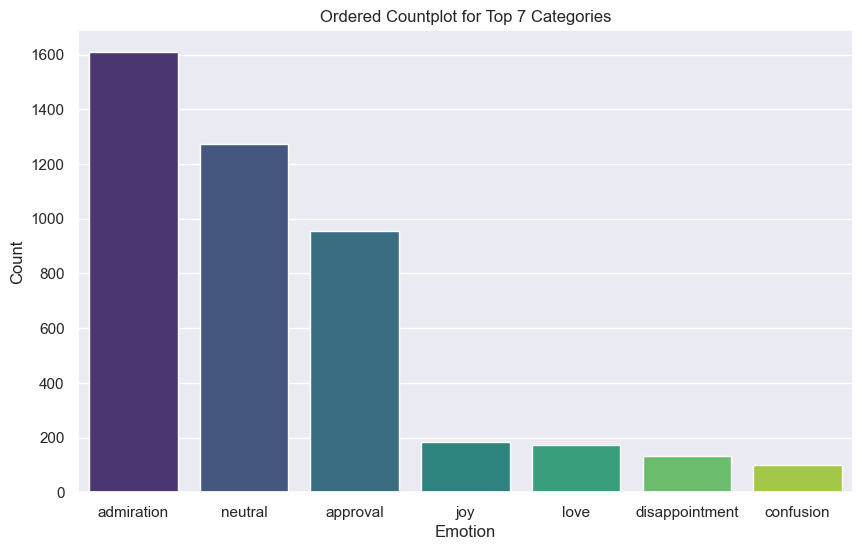

In [44]:
df = new_df.copy()
# Count the occurrences of each category
category_counts = df['Emotion 1'].value_counts()

# Select the top 7 categories
top_categories = category_counts.head(7).index

# Filter the dataframe to include only the top categories
df_filtered = df[df['Emotion 1'].isin(top_categories)]

# Set the plotting style
sns.set(style="darkgrid")

# Plot the ordered countplot for the top 7 categories
plt.figure(figsize=(10, 6))
sns.countplot(x='Emotion 1', data=df_filtered, order=top_categories, palette='viridis')

# Show the plot
plt.title('Ordered Countplot for Top 7 Categories')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.show() 

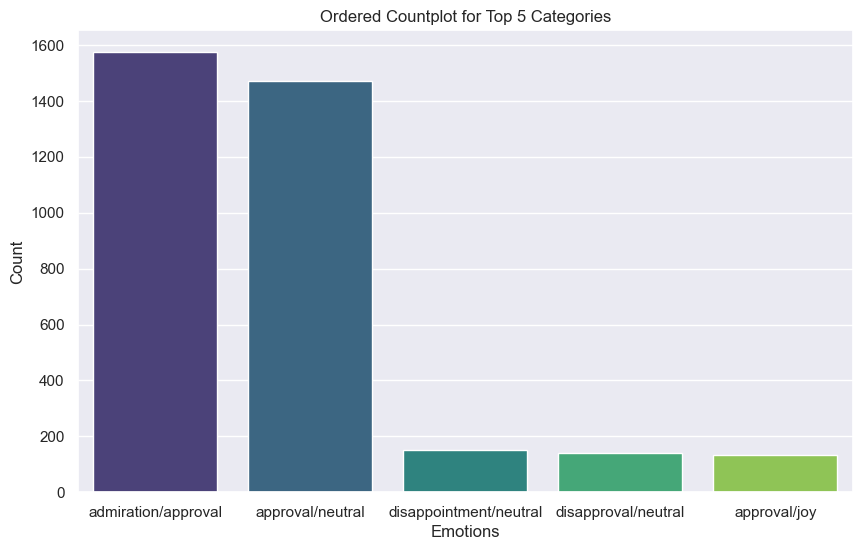

In [45]:
df = new_df.copy() 
#df['Emotions'] =  df['Emotion 1'] + '/' + df['Emotion 2'] 
df['Emotions'] = df.apply(lambda row: '/'.join(sorted([row['Emotion 1'], row['Emotion 2']])), axis=1)
# Count the occurrences of each category
category_counts = df['Emotions'].value_counts()

# Select the top 7 categories
top_categories = category_counts.head(5).index

# Filter the dataframe to include only the top categories
df_filtered = df[df['Emotions'].isin(top_categories)]

# Set the plotting style
sns.set(style="darkgrid")

# Plot the ordered countplot for the top 7 categories
plt.figure(figsize=(10, 6))
sns.countplot(x='Emotions', data=df_filtered, order=top_categories, palette='viridis')

# Show the plot
plt.title('Ordered Countplot for Top 5 Categories')
plt.xlabel('Emotions')
plt.ylabel('Count')
plt.show() 